# ML from DFT data

In [1]:
from Tools.DatasetTools.Commoms import *
from Tools.DatasetTools.DatasetOperator import Dataset, DatasetTester
from Tools.DatasetTools.Tools import get_str_formatted
from sklearn.model_selection import StratifiedKFold
import joblib
import matplotlib
from matplotlib.ticker import FormatStrFormatter
from Tools.DatasetTools.MLConveniences import *

# Parameters 

In [2]:
target_case = 'EF_nmhcp'

In [3]:
DS = Dataset('Fe-Mo', target_name=target_case, remove_phases_query='Phase != "bcc" and Phase != "fcc" and Phase !="hcp"')

Possible models are: **Kernel Ridge, MLP and Random Forest**

In [4]:
ModelName = 'Kernel Ridge'

In [5]:
namefile = ModelName.replace(' ', '')

In [6]:
suffix = f"no_hcp_bcc_fcc_{namefile}" #'CV_restart_folds_inloop''CV_restart_folds_inloop

In [7]:
(DS.BS.Phase == 'hcp').sum()

0

# Targets

In [8]:
plt.rc('text', usetex=False)

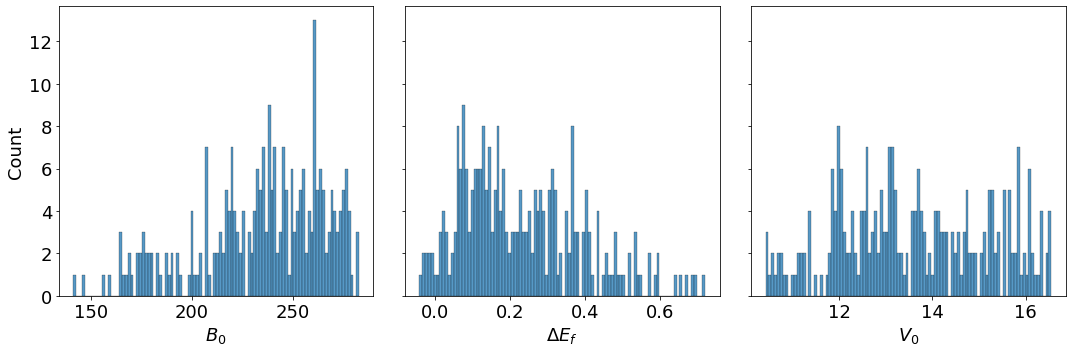

In [9]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5), sharey = True)
sns.histplot( DS.BS['B0'], ax= ax[0], bins=100)
sns.histplot( DS.BS[target_case], ax= ax[1], bins=100)
sns.histplot( DS.BS['V0'], ax= ax[2], bins = 100)
ax[0].set_xlabel('$B_0$')
ax[1].set_xlabel(r'$\Delta E_f$')
ax[2].set_xlabel('$V_0$')
fig.tight_layout()
fig.savefig(f'{DS.dataset}/graphs/{DS.dataset}_target_distributions_{target_case}.eps')

In [10]:
DS.BS.B0.idxmax()

'Fe_pv4Mo_sv2.C15-A2B.NM'

In [11]:
DS.BS.query('B0 < 150')

,,V,E0,B,fit,xc,encut,deltak,ncrash,nelem,...,num_atom_A,num_atom_B,num_atoms,Fe_pv,Mo_sv,Mag,Phase,EF_fmbcc,EF_nmhcp,EF_nmfcc
Fe_pv29.chi.FM,bulk chi.FM,12.050793 A,-8.137580,152.259441 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,1,...,29,0,29,1.0,0.0,FM,chi,0.117648,0.117648,0.117648
Fe_pv6.C15.FM,bulk C15.FM,12.092153 A,-8.111059,148.116428 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.021,0,1,...,6,0,6,1.0,0.0,FM,C15,0.144169,0.144169,0.144169


# Machine Learning 

In [12]:
resultslocation = DS.resultslocation

## Feature sets

In [13]:
Features = DS.Features  # {name: pd.read_pickle(filename) for name, filename in DescriptorFileList.items()}

In [14]:
for name, featuredf in Features.items():
    if 'BOP' in name:
        print (name )

Canonical BOP
0.7dProjections 0.5OS BOP
0.7spProjections 0.5OS BOP
dataset + Canonical BOP
dataset + 0.7dProjections 0.5OS BOP
dataset + 0.7spProjections 0.5OS BOP
Canonical BOP no CNAV
0.7dProjections 0.5OS BOP no CNAV
0.7spProjections 0.5OS BOP no CNAV
dataset + Canonical BOP no CNAV
dataset + 0.7dProjections 0.5OS BOP no CNAV
dataset + 0.7spProjections 0.5OS BOP no CNAV


In [15]:
Features['SOAP_canonicalW_small no CNAV']

,Structure,Mag,SOAP_0_0,SOAP_1_0,SOAP_2_0,SOAP_3_0,SOAP_4_0,SOAP_5_0,SOAP_6_0,SOAP_7_0,...,SOAP_66_0,SOAP_67_0,SOAP_68_0,SOAP_69_0,SOAP_70_0,SOAP_71_0,SOAP_72_0,SOAP_73_0,SOAP_74_0,random
Fe_pv4Mo_sv20.C36-ABBBB.FM,3,1,0.019930,0.000029,0.006891,-0.004995,0.005019,1.565574e-06,0.000008,-0.000009,...,-7.637395e-07,0.000001,-8.913553e-07,0.000003,-8.029796e-06,0.000009,0.000028,-0.000035,0.000044,0.088742
Fe_pv15Mo_sv38.R-AAAABBBBBBB.NM,4,0,0.019948,-0.000009,0.007036,-0.005294,0.005232,7.452985e-07,-0.000004,0.000002,...,-6.421399e-06,0.000011,-9.087895e-06,0.000012,-2.186196e-05,0.000020,0.000042,-0.000041,0.000041,0.827951
Fe_pv2Mo_sv11.mu-BBABB.FM,9,1,0.019938,0.000014,0.006930,-0.005033,0.005025,1.012184e-06,0.000004,-0.000005,...,-5.744602e-06,0.000008,-5.417666e-06,0.000010,-1.682507e-05,0.000014,0.000035,-0.000035,0.000038,0.562304
Fe_pv8Mo_sv22.sigma-BBBAB.NM,10,0,0.019963,-0.000032,0.007075,-0.005269,0.005169,1.823310e-07,-0.000012,0.000008,...,-9.854544e-06,0.000016,-1.369627e-05,0.000019,-3.378020e-05,0.000031,0.000067,-0.000065,0.000067,0.673568
Fe_pv2Mo_sv11.mu-BBBBA.NM,9,0,0.019938,0.000014,0.006930,-0.005033,0.005025,1.012184e-06,0.000004,-0.000005,...,-5.744602e-06,0.000008,-5.417666e-06,0.000010,-1.682507e-05,0.000014,0.000035,-0.000035,0.000038,0.708933
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Fe_pv8Mo_sv16.C36-BAABB.NM,3,0,0.019918,0.000042,0.006939,-0.005313,0.005342,2.230525e-06,0.000011,-0.000012,...,-5.420279e-07,-0.000002,3.061153e-06,0.000002,-3.821824e-06,0.000004,0.000024,-0.000033,0.000046,0.718556
Fe_pv30.sigma.FM,10,1,0.019820,0.000170,0.007022,-0.006735,0.006903,2.253822e-06,0.000059,-0.000058,...,-1.124610e-05,0.000003,9.347744e-06,0.000017,-1.576315e-05,0.000004,0.000053,-0.000066,0.000102,0.043635
Fe_pv6.C15.FM,2,1,0.019775,0.000255,0.006787,-0.006525,0.006893,1.076990e-05,0.000072,-0.000076,...,-2.123679e-05,-0.000001,2.945842e-05,0.000025,5.152223e-07,-0.000033,0.000004,-0.000008,0.000056,0.766945
Mo_sv8.A15.NM,0,0,0.019972,-0.000034,0.006947,-0.004732,0.004670,7.103624e-08,-0.000012,0.000008,...,-1.395295e-05,0.000022,-1.858555e-05,0.000026,-4.503168e-05,0.000040,0.000086,-0.000082,0.000082,0.440743


In [16]:
Features['NOTHREE-ACE no CNAV'].shape

(262, 282)

## BOP features with and without CP averages

In [17]:
# Features.update({name+' no Zeros': clean_zeros(name, features) for name, features in Features.items() if notyetclean(name)} )

## test - train splits

In [18]:
samplesplit = DS.get_samplesplit()

<Axes: xlabel='Phase', ylabel='Count'>

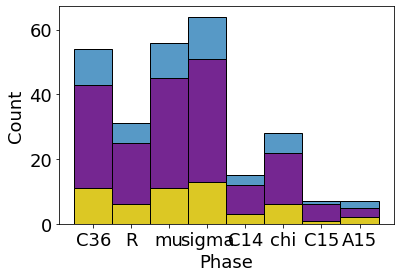

In [19]:
ax = sns.histplot(DS.StructureNames)
sns.histplot(DS.StructureNames.loc[samplesplit['train']], ax = ax, color = 'purple')
sns.histplot(DS.StructureNames.loc[samplesplit['test']], ax = ax, color = 'yellow')

# Models: adjust params

In [20]:
import warnings
warnings.simplefilter('ignore')

In [21]:
Models = {
    'Kernel Ridge': Pipeline([('scaler', StandardScaler()), ('regressor', KernelRidge())]),
    'MLP': Pipeline([('scaler', StandardScaler()), ('regressor', MLPRegressor())]),
    'Random Forest': Pipeline([('regressor', RandomForestRegressor())]),
    'Gaussian Process': Pipeline([('regressor', GaussianProcessRegressor())])
}

In [22]:
from importlib.machinery import SourceFileLoader
MO = SourceFileLoader('MO', 'Tools/DatasetTools/ModelSelection.py').load_module().ModelOptions(DS.dataset)

In [23]:
MO.load_model_options(ModelName)

In [24]:
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, RationalQuadratic, ConstantKernel, ExpSineSquared, DotProduct, Product

##  Features

In [25]:
DS.BS.index[DS.BS.index.str.contains('bcc')]

Index([], dtype='object')

In [26]:
test_bop_feature = '0.7dProjections 0.5OS BOP'

In [27]:
Features[test_bop_feature].index[Features[test_bop_feature].index.str.contains('bcc')]

Index([], dtype='object')

In [28]:
Features[test_bop_feature].index[Features[test_bop_feature].index.str.contains('bcc')]

Index([], dtype='object')

In [29]:
DS.target.index.difference(Features[test_bop_feature].index)

Index([], dtype='object')

In [30]:
for name, thefeatures in Features.items():
    print(name, thefeatures.shape)

atomic (262, 135)
dataset (262, 32)
SOAP_canonicalW_small (262, 453)
SOAP_specific_small (262, 1653)
Pyscal (262, 15)
ACE (262, 1803)
NOZERO-ACE (262, 777)
NOZERO_NOONE-ACE (262, 375)
NOZERO_NOONE_NOTWO-ACE (262, 375)
NOTHREE-ACE (262, 1677)
NOTHREE-NOTWO-ACE (262, 951)
NOTHREE-NOTWO_NOONE-ACE (262, 495)
Canonical ACE (262, 417)
Canonical BOP (262, 405)
0.7dProjections 0.5OS BOP (262, 417)
0.7spProjections 0.5OS BOP (262, 429)
dataset + Canonical BOP (262, 434)
dataset + 0.7dProjections 0.5OS BOP (262, 446)
dataset + 0.7spProjections 0.5OS BOP (262, 458)
atomic no CNAV (262, 135)
dataset no CNAV (262, 17)
SOAP_canonicalW_small no CNAV (262, 78)
SOAP_specific_small no CNAV (262, 278)
Pyscal no CNAV (262, 5)
ACE no CNAV (262, 303)
NOZERO-ACE no CNAV (262, 132)
NOZERO_NOONE-ACE no CNAV (262, 65)
NOZERO_NOONE_NOTWO-ACE no CNAV (262, 65)
NOTHREE-ACE no CNAV (262, 282)
NOTHREE-NOTWO-ACE no CNAV (262, 161)
NOTHREE-NOTWO_NOONE-ACE no CNAV (262, 85)
Canonical ACE no CNAV (262, 72)
Canonical BOP

In [31]:
Features[test_bop_feature].index[Features[test_bop_feature].index.str.contains('bcc')]

Index([], dtype='object')

# Feature Selection

In [32]:
suffix

'no_hcp_bcc_fcc_KernelRidge'

In [33]:
feature_concat_resul_loc = os.path.join(DS.dataset, 'results', f'concatenation_results_{target_case}_{suffix}.pkl')  
if os.path.exists(feature_concat_resul_loc):
    with open(feature_concat_resul_loc, 'rb') as pkl:
        savedFCresults = pickle.load(pkl)
else:
    savedFCresults = {}

In [34]:
#with open(feature_concat_resul_loc, 'wb') as f:
#    pickle.dump(savedFCresults, f)

In [35]:
FCresults = {}

In [36]:
for combi, selectionloop in savedFCresults.items():
    print (combi, len(selectionloop))
    FCresults[combi] = []
    for thisloop in selectionloop:
        badnews =  'random' in thisloop.index
        if badnews:
            print(badnews, thisloop.index.get_loc('random'),'/', len (thisloop))
            thisloop=thisloop.loc[:'random'].iloc[:-1]
        else:
            print (badnews, len(thisloop))
        if len(thisloop) < 1:
            continue
        FCresults[combi].append(thisloop)

('Kernel Ridge', 'atomic') 3
False 8
False 8
False 8
('Kernel Ridge', 'dataset') 3
False 21
False 8
False 17
('Kernel Ridge', 'Canonical ACE') 12
False 202
False 199
False 132
True 95 / 203
True 143 / 201
False 198
False 198
True 200 / 201
True 148 / 197
True 3 / 77
True 63 / 203
True 78 / 200
('Kernel Ridge', 'Canonical BOP') 13
False 18
False 51
False 145
False 206
False 100
False 150
False 55
False 122
False 112
False 163
False 59
False 171
True 36 / 195
('Kernel Ridge', 'ACE no CNAV') 10
False 105
False 101
False 44
False 60
False 75
False 88
False 114
False 84
False 96
False 129
('Kernel Ridge', 'ACE') 12
False 208
False 220
False 215
False 98
False 242
False 251
False 248
False 251
False 251
False 251
False 251
False 228
('Kernel Ridge', '0.7dProjections 0.5OS BOP') 12
False 134
False 192
False 131
False 126
False 122
False 176
False 192
False 126
False 132
False 205
True 7 / 199
False 185
('Kernel Ridge', '0.7spProjections 0.5OS BOP') 13
False 133
False 106
False 175
False 188
F

In [37]:
for combi, selectionloop in FCresults.items():
    print (combi)
    for thisloop in selectionloop:
        badnews =  'random' in thisloop.index
        if badnews:
            print(badnews, thisloop.index.get_loc('random'),'/', len (thisloop))
        else:
            print(badnews, len (thisloop))

('Kernel Ridge', 'atomic')
False 8
False 8
False 8
('Kernel Ridge', 'dataset')
False 21
False 8
False 17
('Kernel Ridge', 'Canonical ACE')
False 202
False 199
False 132
False 95
False 143
False 198
False 198
False 200
False 148
False 3
False 63
False 78
('Kernel Ridge', 'Canonical BOP')
False 18
False 51
False 145
False 206
False 100
False 150
False 55
False 122
False 112
False 163
False 59
False 171
False 36
('Kernel Ridge', 'ACE no CNAV')
False 105
False 101
False 44
False 60
False 75
False 88
False 114
False 84
False 96
False 129
('Kernel Ridge', 'ACE')
False 208
False 220
False 215
False 98
False 242
False 251
False 248
False 251
False 251
False 251
False 251
False 228
('Kernel Ridge', '0.7dProjections 0.5OS BOP')
False 134
False 192
False 131
False 126
False 122
False 176
False 192
False 126
False 132
False 205
False 7
False 185
('Kernel Ridge', '0.7spProjections 0.5OS BOP')
False 133
False 106
False 175
False 188
False 149
False 179
False 144
False 239
False 115
False 104
False 7

In [38]:
FCresults.keys()

dict_keys([('Kernel Ridge', 'atomic'), ('Kernel Ridge', 'dataset'), ('Kernel Ridge', 'Canonical ACE'), ('Kernel Ridge', 'Canonical BOP'), ('Kernel Ridge', 'ACE no CNAV'), ('Kernel Ridge', 'ACE'), ('Kernel Ridge', '0.7dProjections 0.5OS BOP'), ('Kernel Ridge', '0.7spProjections 0.5OS BOP'), ('Kernel Ridge', 'atomic no CNAV'), ('Kernel Ridge', 'dataset no CNAV'), ('Kernel Ridge', '0.7dProjections 0.5OS BOP no CNAV'), ('Kernel Ridge', '0.7spProjections 0.5OS BOP no CNAV'), ('Kernel Ridge', 'SOAP_specific_small'), ('Kernel Ridge', 'SOAP_specific_small no CNAV'), ('Kernel Ridge', 'Canonical ACE no CNAV'), ('Kernel Ridge', 'Canonical BOP no CNAV'), ('Kernel Ridge', 'SOAP_canonicalW_small'), ('Kernel Ridge', 'SOAP_canonicalW_small no CNAV'), ('Kernel Ridge', '0.7dProjections 10scf 8.0jii BOP'), ('Kernel Ridge', '0.7dProjections 10scf 8.0jii BOP no CNAV'), ('Kernel Ridge', '0.7dProjections 100scf 8.0jii BOP'), ('Kernel Ridge', '0.7dProjections 100scf 8.0jii BOP no CNAV')])

In [39]:
for combi, results in FCresults.items():
#    if 'SOAP' in combi[1]:
    print (combi, len(results))

('Kernel Ridge', 'atomic') 3
('Kernel Ridge', 'dataset') 3
('Kernel Ridge', 'Canonical ACE') 12
('Kernel Ridge', 'Canonical BOP') 13
('Kernel Ridge', 'ACE no CNAV') 10
('Kernel Ridge', 'ACE') 12
('Kernel Ridge', '0.7dProjections 0.5OS BOP') 12
('Kernel Ridge', '0.7spProjections 0.5OS BOP') 13
('Kernel Ridge', 'atomic no CNAV') 10
('Kernel Ridge', 'dataset no CNAV') 10
('Kernel Ridge', '0.7dProjections 0.5OS BOP no CNAV') 10
('Kernel Ridge', '0.7spProjections 0.5OS BOP no CNAV') 10
('Kernel Ridge', 'SOAP_specific_small') 10
('Kernel Ridge', 'SOAP_specific_small no CNAV') 10
('Kernel Ridge', 'Canonical ACE no CNAV') 10
('Kernel Ridge', 'Canonical BOP no CNAV') 64
('Kernel Ridge', 'SOAP_canonicalW_small') 10
('Kernel Ridge', 'SOAP_canonicalW_small no CNAV') 10
('Kernel Ridge', '0.7dProjections 10scf 8.0jii BOP') 1
('Kernel Ridge', '0.7dProjections 10scf 8.0jii BOP no CNAV') 1
('Kernel Ridge', '0.7dProjections 100scf 8.0jii BOP') 0
('Kernel Ridge', '0.7dProjections 100scf 8.0jii BOP no CNA

In [40]:
FCresults[('Kernel Ridge', 'atomic')][0]

,train1,test1,params,test,train
MagpieData mean GSmagmom,0.144251,0.144828,"{'regressor__alpha': 1.0, 'regressor__coef0': ...",0.145459,0.144785
Structure,0.127288,0.137680,"{'regressor__alpha': 1.0, 'regressor__coef0': ...",0.132305,0.129509
MagpieData maximum AtomicWeight,0.125956,0.140145,"{'regressor__alpha': 1.0, 'regressor__coef0': ...",0.132191,0.130325
MagpieData minimum AtomicWeight,0.123427,0.138453,"{'regressor__alpha': 1.0, 'regressor__coef0': ...",0.136244,0.129829
MagpieData mode GSmagmom,0.115431,0.138314,"{'regressor__alpha': 0.1, 'regressor__coef0': ...",0.141031,0.123262
MagpieData mode GSvolume_pa,0.111563,0.138033,"{'regressor__alpha': 0.1, 'regressor__coef0': ...",0.144284,0.118144
Mag,0.103822,0.151017,"{'regressor__alpha': 1.0, 'regressor__coef0': ...",0.151147,0.139858
MagpieData avg_dev MeltingT,0.094775,0.150136,"{'regressor__alpha': 1.0, 'regressor__coef0': ...",0.150883,0.138520


In [41]:
nowantoplot = [''] # ['0.6dProjections OS BOP','0.8 Projections OS BOP', 'Projections OS BOP', 'atomic no CNAV', 'dataset no CNAV', 'SOAP_canonicalFe']

In [42]:
iwanttoplot = [combi[1] for combi in FCresults.keys() if combi[0] == ModelName and combi[1] not in nowantoplot and len(FCresults[combi])>0]# and 'no CNAV' not in combi[1] and combi[1] != 'ACE']

## Number of curves for each regressor

In [43]:
for featurename in iwanttoplot:
    print(featurename, len(FCresults[(ModelName, featurename)]))

atomic 3
dataset 3
Canonical ACE 12
Canonical BOP 13
ACE no CNAV 10
ACE 12
0.7dProjections 0.5OS BOP 12
0.7spProjections 0.5OS BOP 13
atomic no CNAV 10
dataset no CNAV 10
0.7dProjections 0.5OS BOP no CNAV 10
0.7spProjections 0.5OS BOP no CNAV 10
SOAP_specific_small 10
SOAP_specific_small no CNAV 10
Canonical ACE no CNAV 10
Canonical BOP no CNAV 64
SOAP_canonicalW_small 10
SOAP_canonicalW_small no CNAV 10
0.7dProjections 10scf 8.0jii BOP 1
0.7dProjections 10scf 8.0jii BOP no CNAV 1


In [44]:
iwanttoplot

['atomic',
 'dataset',
 'Canonical ACE',
 'Canonical BOP',
 'ACE no CNAV',
 'ACE',
 '0.7dProjections 0.5OS BOP',
 '0.7spProjections 0.5OS BOP',
 'atomic no CNAV',
 'dataset no CNAV',
 '0.7dProjections 0.5OS BOP no CNAV',
 '0.7spProjections 0.5OS BOP no CNAV',
 'SOAP_specific_small',
 'SOAP_specific_small no CNAV',
 'Canonical ACE no CNAV',
 'Canonical BOP no CNAV',
 'SOAP_canonicalW_small',
 'SOAP_canonicalW_small no CNAV',
 '0.7dProjections 10scf 8.0jii BOP',
 '0.7dProjections 10scf 8.0jii BOP no CNAV']

In [45]:
pallete = sns.color_palette(n_colors=len(iwanttoplot))

In [46]:
colors = {name: c for name, c in zip(iwanttoplot, pallete)}

In [47]:
# iwanttoplot = ['atomic', 'dataset', 'Canonical BOP', 'dataset + Canonical BOP', 'Projections BOP', 'dataset + Projections BOP', 'Projections sOS BOP', 'dataset + Projections sOS BOP' ]
#iwanttoplot = ['ACE','SOAP_specific_small',  'Canonical BOP', 
#iwanttoplot = ['Projections OS BOP']#, 'Projections sOS BOP']#, 'SOAP_canonicalW',

In [48]:
folder = StratifiedKFold(shuffle=True)
folds_generator = folder.split(DS.samplesplit['train'], DS.StructureNames[DS.samplesplit['train']])
train_folds = list(folds_generator)
TestCV = GridSearchCV(Models[ModelName], MO.modeloptions[ModelName], cv = train_folds, return_train_score=True)

In [49]:
FittedGS = {}

In [50]:
MO.modeloptions

{'Kernel Ridge': {'regressor__alpha': [1.0, 0.1, 0.01],
  'regressor__kernel': ['polynomial'],
  'regressor__degree': [2, 3, 4, 5],
  'regressor__coef0': [0, 1, 2, 3, 4, 5]}}

# Some old code
``` python
# DS.Features.keys(): #['Canonical BOP']:
for featurename in iwanttoplot: #FittedModels.items():
    print(featurename)
    if 'random' not in Features[featurename]:
        Features[featurename]['random'] = np.random.rand(DS.target.shape[0])
    corrs = pd.concat([Features[featurename], DS.target], axis=1).corr().abs()[target_case]
    
    reasonable_features = corrs[corrs > corrs['random']].index.difference([target_case])
    combi = (ModelName, featurename)
#   model = copy.deepcopy(fmodel.best_estimator_)
    if len(FCresults[combi]) >= 1 :
        continue
    FittedGS[combi] = copy.deepcopy(TestCV)
    FC = FeatureConcatenate(DS, FittedGS[combi],  MO.modeloptions[ModelName]) #fmodel.best_params_,)model_params_grid =
    FCresults[combi].append (FC.get_best_features_list(combi[1], num_features = 2, max_workers=3, search_only = reasonable_features))#DS.Features[combi[1]].shape[1]
    with open(feature_concat_resul_loc, 'wb') as pkl:
        pickle.dump(FCresults, pkl)
```

In [51]:
#with open(feature_concat_resul_loc, 'wb') as pkl:
#    pickle.dump(FCresults, pkl)

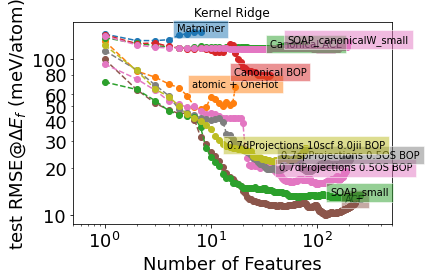

In [52]:
from matplotlib.ticker import FormatStrFormatter
fig, axes = plt.subplots()
for combi, result in FCresults.items():
    if len(result) < 1:
        continue
    if combi[0] != ModelName:
        continue
    if combi[1] not in iwanttoplot:
        continue
    if 'no CNAV' in combi[1]:
        continue
#    if ' OS ' in combi[1]:
#        continue
    nfeats = result[-1].shape[0]
    x=np.linspace(1,nfeats, nfeats)
    legend = combi[1].replace('dataset', 'polyhedra')
    legend = legend.replace('atomic', 'Matminer')\
        .replace('_specific','').replace('0.7 ','')\
        .replace('polyhedra','atomic + OneHot')\
        .replace('Projections OS BOP', 'Bond Specific BOP')
    if 'test' not in result[-1].keys():
        continue
    y = result[-1]['test'].values*1000
    axes.plot(x, y ,'--o',c=colors[combi[1]], label=legend)
    text = axes.text(x[-1], y[-1], legend, horizontalalignment='center')#, backgroundcolor='white', alpha=0.5)
    text.set_bbox(dict(facecolor=colors[combi[1]], alpha=0.5,edgecolor='white'))
axes.set_xscale('log')
axes.set_ylabel(r'test RMSE@$\Delta E_f$ (meV/atom)')
axes.set_xlabel('Number of Features')
axes.tick_params(axis='y', which='minor')
axes.set_yscale('log', subs = [0.2, 0.3, 0.4,0.5, 0.6, 0.8])
axes.yaxis.set_minor_formatter(FormatStrFormatter("%.0f"))
axes.yaxis.set_major_formatter(FormatStrFormatter("%.0f"))
#plt.legend(bbox_to_anchor=(0.6,0.5))
axes.set_xlim([0.5, 0.5e3])
axes.set_title(ModelName)
fig.tight_layout()
nameforfile = ModelName.replace(' ','')
fig.savefig(f'{DS.dataset}/graphs/{DS.dataset}_{nameforfile}_LearningCurves_{target_case}_{nameforfile}.pdf')

In [53]:
'Mag' in FCresults[(ModelName, test_bop_feature )][-1].index

True

In [54]:
#'Structure' in
theindex = FCresults[(ModelName, test_bop_feature )][-1].index

In [55]:
FCresults[(ModelName, test_bop_feature )][-1].reset_index()[theindex=='Structure']

,index,train1,test1,params,test,train


In [56]:
combi = (ModelName, test_bop_feature)
selected_pos = FCresults[combi][-1].index[0]
y_pos = FCresults[combi][-1]['test']*1000
x = np.linspace(1, len(y_pos), len(y_pos))
axes.annotate(get_str_formatted(selected_pos), (x[0], y_pos[0]-5), xytext=(x[0]-0.1, y_pos[0]-40), arrowprops={'facecolor':'black'})
selected_next = FCresults[combi][-1].index[1]
axes.annotate(get_str_formatted(selected_next), (x[1], y_pos[1]), xytext=(x[1]*2, y_pos[1]+20), arrowprops={'facecolor':'black'})
ymag = y_pos[y_pos.index=='Mag']['Mag']
xmag = x[y_pos.index=='Mag']
axes.annotate('Mag', (xmag-0.1, ymag-1), xytext=(xmag/5, ymag-10), arrowprops={'facecolor':'black'})
fig.tight_layout()
nameforfile = ModelName.replace(' ','')
fig.savefig(f'{DS.dataset}/graphs/{DS.dataset}_{nameforfile}_LearningCurves_annotated_{target_case}_CV.pdf')

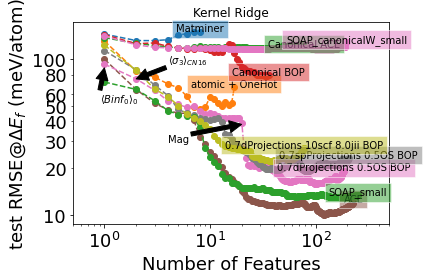

In [57]:
fig

## Feature Selection

In [58]:
iwanttoplot_all = [feature for feature in iwanttoplot if 'no CNAV' not in feature and 'dataset' not in feature and 'atomic' in feature]

In [59]:
iwanttoplot_all = {
    test_bop_feature: 'BOP',  
    'ACE':'ACE',
    'SOAP_specific_small': 'SOAP',
    'dataset': 'atomic + OneHot', 
    'Canonical BOP': 'Canonical BOP',
    'SOAP_canonicalW_small' : 'Canonical SOAP',
    'Canonical ACE': 'Canonical ACE'
}

In [60]:
from matplotlib import __version__

In [61]:
iwanttoplot_all

{'0.7dProjections 0.5OS BOP': 'BOP',
 'ACE': 'ACE',
 'SOAP_specific_small': 'SOAP',
 'dataset': 'atomic + OneHot',
 'Canonical BOP': 'Canonical BOP',
 'SOAP_canonicalW_small': 'Canonical SOAP',
 'Canonical ACE': 'Canonical ACE'}

In [62]:
def plot_panel_learning_curves(feature_list: dict):# -> list[matplotlib.axes._subplots.Axes]: 
    nplots = len(feature_list)
    width = plt.rcParams['figure.figsize'][0]*(3/5)*nplots
    height = plt.rcParams['figure.figsize'][1]
    fig, axes = plt.subplots(1,nplots, figsize=(width, height), sharey = True)# figsize=(width, 5*width/13),
    for (featurename, featurelabel), ax in zip(feature_list.items(), axes):
        combi = (ModelName, featurename)
        ax.set_title(featurelabel)
        results = FCresults[combi]
        for j, result in enumerate(results):
            x = np.linspace(1, result.shape[0], result.shape[0])
            if 'test' not in result.keys():
                continue
            sns.scatterplot(x=x, y=result['test']*1000, ax=ax)
        N = Features[featurename].shape[1]
        NL = len(results)
        ax.legend([],[],title=f'N = {N}\n NL = {NL}')
        ax.set_yscale('log', subs=[2, 6, 10])
        ax.set_xscale('log')
        ax.xaxis.set_major_formatter(FormatStrFormatter("%.0f"))
#    ax.set_ylim([19, 110])
    ax.yaxis.set_minor_formatter(FormatStrFormatter("%.0f"))
    ax.yaxis.set_major_formatter(FormatStrFormatter("%.0f"))
    ax.tick_params(axis='y', which = 'minor')
    axes[0].set_xticks([1, 5, 10])
    axes[0].set_ylabel(r'test RMSE @$\Delta E_f$ (meV/at)')
    fig.supxlabel('Number of features')
    return fig, axes
#    axes[i-1].set_xticklabels('')
#axes[0].yaxis.set_major_formatter(FormatStrFormatter("%.0e"))

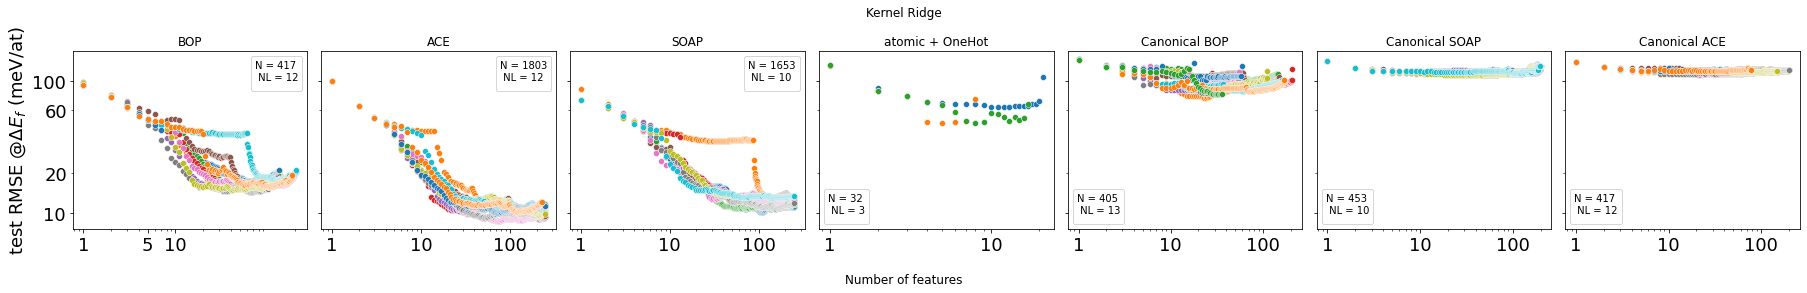

In [63]:
fig, axes = plot_panel_learning_curves(iwanttoplot_all)
nameinfile = ModelName.replace(' ','')
fig.suptitle(ModelName)
fig.tight_layout()
fig.savefig(os.path.join(DS.dataset, 'graphs', f'{DS.dataset}_{nameinfile}_learning_curves_tovote.pdf'))

# Feature transformers

In [64]:
from sklearn.preprocessing import FunctionTransformer
from sklearn.base import RegressorMixin
from Tools.DatasetTools.MLConveniences import filter_features, get_optimal_features

In [65]:
def get_optimal_feature_score(FeatureScoreData:pd.core.frame.DataFrame):
    thisatmin = FeatureScoreData['test'].argmin()
    return FeatureScoreData[:thisatmin]

In [66]:
#def get_optimal_features(FeatureScoreData:pd.core.frame.DataFrame, remove_structure = False):
#    thisatmin = FeatureScoreData['test'].argmin()
#    optimal_features = FeatureScoreData.index[:thisatmin]
#    if remove_structure:
#        optimal_features=optimal_features[optimal_features != 'Structure']
#    return optimal_features # FeatureScoreData.index[:thisatmin]

In [67]:
#def filter_features (Features_DF: pd.core.frame.DataFrame, learning_curve = pd.core.frame.DataFrame, remove_structure = True):
#    if 'params' not in learning_curve.columns:
#        raise ValueError('the learning curve provided is not an evaluation of best features')
#    columns = get_optimal_features(learning_curve,remove_structure = remove_structure)
#    return Features_DF[columns]

#def get_optimal_feature_names(Features_DF: pd.core.frame.DataFrame, learning_curve = pd.core.frame.DataFrame):
#    columns = get_optimimal_features(learning_curve)
#    return columns


In [68]:
#class AverageEnsambleRegressor():
#    def __init__(self, named_estimators = list[tuple[str, RegressorMixin]]):
#        self.named_estimators_ : list[tuple[str, RegressorMixin]] = named_estimators
#
#    def fit(self, _X : pd.core.frame.DataFrame , _Y : pd.core.series.Series) -> pd.core.series.Series:
#
#        for name, estimator in self.named_estimators_:
#            estimator.fit(_X, _Y)
#
#    def predict(self, _X : pd.core.frame.DataFrame) -> pd.core.series.Series:
#
#        self.predictions_ = pd.concat(
#            [pd.Series(estimator.predict(_X), name=name, index=_X.index) for name, estimator in self.named_estimators_],
#            axis=1
#        )
#
#        return self.predictions_.mean(axis=1)
#
#    def get_prediction_std(self):
#        if not hasattr(self, 'predictions_'):
#            pdb.set_trace()
#            raise NameError('you must fit the models first')
#
#        err = self.predictions_.std(axis=1)
#        return err

In [69]:
combi = (ModelName, test_bop_feature)

In [70]:
RegresorsBag = {}

In [71]:
from sklearn.ensemble import VotingRegressor

In [72]:
VotedScores = {}
AveragedScores = {}

In [73]:
voting_regressor = {}
average_regressor = {}
indexedregressorbag = {}

## Voting Regressor based on regressor bag

In [74]:
import logging
Logger = logging.getLogger()
Logger.setLevel(logging.INFO)

In [75]:
combi[1]

'0.7dProjections 0.5OS BOP'

In [76]:
FCresults.keys()

dict_keys([('Kernel Ridge', 'atomic'), ('Kernel Ridge', 'dataset'), ('Kernel Ridge', 'Canonical ACE'), ('Kernel Ridge', 'Canonical BOP'), ('Kernel Ridge', 'ACE no CNAV'), ('Kernel Ridge', 'ACE'), ('Kernel Ridge', '0.7dProjections 0.5OS BOP'), ('Kernel Ridge', '0.7spProjections 0.5OS BOP'), ('Kernel Ridge', 'atomic no CNAV'), ('Kernel Ridge', 'dataset no CNAV'), ('Kernel Ridge', '0.7dProjections 0.5OS BOP no CNAV'), ('Kernel Ridge', '0.7spProjections 0.5OS BOP no CNAV'), ('Kernel Ridge', 'SOAP_specific_small'), ('Kernel Ridge', 'SOAP_specific_small no CNAV'), ('Kernel Ridge', 'Canonical ACE no CNAV'), ('Kernel Ridge', 'Canonical BOP no CNAV'), ('Kernel Ridge', 'SOAP_canonicalW_small'), ('Kernel Ridge', 'SOAP_canonicalW_small no CNAV'), ('Kernel Ridge', '0.7dProjections 10scf 8.0jii BOP'), ('Kernel Ridge', '0.7dProjections 10scf 8.0jii BOP no CNAV'), ('Kernel Ridge', '0.7dProjections 100scf 8.0jii BOP'), ('Kernel Ridge', '0.7dProjections 100scf 8.0jii BOP no CNAV')])

In [77]:
for combi, learningcurvelist in FCresults.items():
    if combi[1] not in Features.keys():
        continue
    for i, learningcurve in enumerate(learningcurvelist):
        intersection = Features[combi[1]].columns.intersection(learningcurve.index)
        print(f'learning curve {i} from {combi} generates {len(intersection)} transform')
        if len(intersection) == 1:
            print(intersection)


learning curve 0 from ('Kernel Ridge', 'atomic') generates 8 transform
learning curve 1 from ('Kernel Ridge', 'atomic') generates 8 transform
learning curve 2 from ('Kernel Ridge', 'atomic') generates 8 transform
learning curve 0 from ('Kernel Ridge', 'dataset') generates 21 transform
learning curve 1 from ('Kernel Ridge', 'dataset') generates 8 transform
learning curve 2 from ('Kernel Ridge', 'dataset') generates 17 transform
learning curve 0 from ('Kernel Ridge', 'Canonical ACE') generates 202 transform
learning curve 1 from ('Kernel Ridge', 'Canonical ACE') generates 199 transform
learning curve 2 from ('Kernel Ridge', 'Canonical ACE') generates 132 transform
learning curve 3 from ('Kernel Ridge', 'Canonical ACE') generates 95 transform
learning curve 4 from ('Kernel Ridge', 'Canonical ACE') generates 143 transform
learning curve 5 from ('Kernel Ridge', 'Canonical ACE') generates 198 transform
learning curve 6 from ('Kernel Ridge', 'Canonical ACE') generates 198 transform
learning c

In [78]:
for combi, LearningCurveList in FCresults.items():
    Logger.info(f'{combi}')
    RegresorsBag[combi] = []
    if combi[1] not in Features:
        continue
    X = Features[combi[1]]
    if combi[1] not in Features.keys():
        continue
    if combi[0] != ModelName:
        continue
    if len(LearningCurveList) < 1:
        continue
    for LearningCurve in LearningCurveList:
        if len(LearningCurve) < 1:
            continue
        transformer = FunctionTransformer(
            filter_features, kw_args = {'learning_curve' : LearningCurve, 'remove_structure' : True},
        )
        X_transformed = transformer.transform(X)
        if len(X_transformed.columns) < 1:
            Logger.info('a transformer wont be included')
            continue
        RegresorsBag[combi].append(copy.deepcopy(Models[ModelName])) 
        RegresorsBag[combi][-1].steps.insert(0, ['feature_selection', transformer])
        thiscurve = LearningCurve
        RegresorsBag[combi][-1].set_params(**thiscurve.params.iloc[-1])

    if len(RegresorsBag[combi]) < 1:
        continue
    indexedregressorbag[combi] = [(str(i), thisregressor) for i, thisregressor in enumerate(RegresorsBag[combi])]

    voting_regressor[combi] = VotingRegressor(indexedregressorbag[combi])


INFO:root:('Kernel Ridge', 'atomic')
INFO:root:('Kernel Ridge', 'dataset')
INFO:root:('Kernel Ridge', 'Canonical ACE')
INFO:root:('Kernel Ridge', 'Canonical BOP')
INFO:root:('Kernel Ridge', 'ACE no CNAV')
INFO:root:('Kernel Ridge', 'ACE')
INFO:root:('Kernel Ridge', '0.7dProjections 0.5OS BOP')
INFO:root:('Kernel Ridge', '0.7spProjections 0.5OS BOP')
INFO:root:('Kernel Ridge', 'atomic no CNAV')
INFO:root:a transformer wont be included
INFO:root:a transformer wont be included
INFO:root:('Kernel Ridge', 'dataset no CNAV')
INFO:root:('Kernel Ridge', '0.7dProjections 0.5OS BOP no CNAV')
INFO:root:('Kernel Ridge', '0.7spProjections 0.5OS BOP no CNAV')
INFO:root:('Kernel Ridge', 'SOAP_specific_small')
INFO:root:('Kernel Ridge', 'SOAP_specific_small no CNAV')
INFO:root:('Kernel Ridge', 'Canonical ACE no CNAV')
INFO:root:('Kernel Ridge', 'Canonical BOP no CNAV')
INFO:root:('Kernel Ridge', 'SOAP_canonicalW_small')
INFO:root:('Kernel Ridge', 'SOAP_canonicalW_small no CNAV')
INFO:root:('Kernel Rid

In [79]:
voting_regressor[('Kernel Ridge', 'atomic')]

VotingRegressor(estimators=[('0',
                             Pipeline(steps=[['feature_selection',
                                              FunctionTransformer(func=<function filter_features at 0x7f42ab85bb80>,
                                                                  kw_args={'learning_curve':                                    train1     test1  \
MagpieData mean GSmagmom         0.144251  0.144828   
Structure                        0.127288  0.137680   
MagpieData maximum AtomicWeight  0.125956  0.140145   
MagpieData minimum AtomicWeight  0.123427  0.138453   
MagpieData mode GSmagmom...
MagpieData maximum Row                0.132191  0.130325  
MagpieData minimum Electronegativity  0.134022  0.127423  
MagpieData mode GSmagmom              0.143293  0.118229  
MagpieData mode AtomicWeight          0.146694  0.114140  
Mag                                   0.151147  0.139858  
MagpieData avg_dev GSmagmom           0.150883  0.138520  ,
                                                                           'remove_structure': True})],
                                             ('scaler', StandardScaler()),
                                             ('regressor',
                                              KernelRidge(alpha=1.0, degree=2,
                                                          kernel='polynomial'))]))])

In [80]:
y = DS.target.loc[DS.samplesplit['train']]
for combi, votingregressor in voting_regressor.items():
    xtrain = Features[combi[1]].loc[DS.samplesplit['train']]
    voting_regressor[combi].fit(xtrain, y )


    VotedScores[combi] = score_fitted_model(
        voting_regressor[combi], 
        Features[combi[1]].loc[DS.samplesplit['train']],
        Features[combi[1]].loc[DS.samplesplit['test']],
        DS.target[DS.samplesplit['train']],
        DS.target[DS.samplesplit['test']])
    VotedScores[combi]['orig_len'] = Features[combi[1]].shape[1]

In [81]:
VotedScores[( 'Kernel Ridge', 'atomic' )]

{'test': 0.1572427306413838, 'train': 0.14645701182697618, 'orig_len': 135}

In [82]:
for combi, votingregressor in voting_regressor.items():
    for index, pipeline in votingregressor.estimators:
        pipeline.named_steps['feature_selection'].func#__dict__.keys()
        learning_curve = pipeline.named_steps['feature_selection'].kw_args['learning_curve']
        transformed_features = pipeline.named_steps['feature_selection'].transform(Features[combi[-1]])
        has_struc = 'Structure' in transformed_features.columns
        where_struc = None
        if has_struc: 
            where_struc = transformed_features.columns.get_loc('Structure')
            print(combi, len(learning_curve), 'transformed has structure: ',  has_struc, where_struc)

# SAVE THE REGRESSOR!

In [83]:
regresorbag_file =os.path.join(DS.dataset, 'results', f'regressors_bag_{nameforfile}.pkl')

In [84]:
indexedbags_file = os.path.join(DS.dataset, 'results', f'indexed_bag_{nameforfile}.pkl')

In [85]:
regressor_file = os.path.join(DS.dataset, 'results', f'voting_regressor_{nameforfile}.pkl')

In [86]:
joblib.dump(RegresorsBag, regresorbag_file)
joblib.dump(indexedregressorbag, indexedbags_file)
joblib.dump(voting_regressor, regressor_file)

['Fe-Mo/results/voting_regressor_KernelRidge.pkl']

In [87]:
voting_regressor = joblib.load(regressor_file)

In [88]:
os.path.exists(regressor_file)

True

In [89]:
voting_regressor[(ModelName, 'atomic')]

VotingRegressor(estimators=[('0',
                             Pipeline(steps=[['feature_selection',
                                              FunctionTransformer(func=<function filter_features at 0x7f42ab85bb80>,
                                                                  kw_args={'learning_curve':                                    train1     test1  \
MagpieData mean GSmagmom         0.144251  0.144828   
Structure                        0.127288  0.137680   
MagpieData maximum AtomicWeight  0.125956  0.140145   
MagpieData minimum AtomicWeight  0.123427  0.138453   
MagpieData mode GSmagmom...
MagpieData maximum Row                0.132191  0.130325  
MagpieData minimum Electronegativity  0.134022  0.127423  
MagpieData mode GSmagmom              0.143293  0.118229  
MagpieData mode AtomicWeight          0.146694  0.114140  
Mag                                   0.151147  0.139858  
MagpieData avg_dev GSmagmom           0.150883  0.138520  ,
                                                                           'remove_structure': True})],
                                             ('scaler', StandardScaler()),
                                             ('regressor',
                                              KernelRidge(alpha=1.0, degree=2,
                                                          kernel='polynomial'))]))])

In [90]:
err_test = {}
for (featurename, featuretag), ax in zip(iwanttoplot_all.items(), axes):
    ax.grid('on')
    if featurename not in Features.keys():
        continue
    combi = (ModelName, featurename)
    if combi not in voting_regressor.keys():
        continue
    bagging_regressor = voting_regressor[combi]
    err_test[featurename] = (bagging_regressor.predict(Features[featurename].loc[DS.samplesplit['test']]) - DS.target[DS.samplesplit['test']]).abs()

In [91]:
min_err_test =min( [  err.min() for err in err_test.values() ] )
max_err_test =min( [  err.max() for err in err_test.values() ] )
logbins = np.logspace(np.log10(min_err_test*1000), np.log10(max_err_test*1000), 10)

In [92]:
VotedScores

{('Kernel Ridge', 'atomic'): {'test': 0.1572427306413838,
  'train': 0.14645701182697618,
  'orig_len': 135},
 ('Kernel Ridge', 'dataset'): {'test': 0.0747319602989652,
  'train': 0.05735236794029233,
  'orig_len': 32},
 ('Kernel Ridge', 'Canonical ACE'): {'test': 0.12983909988685804,
  'train': 0.1188943708321683,
  'orig_len': 417},
 ('Kernel Ridge', 'Canonical BOP'): {'test': 0.09308488751834836,
  'train': 0.08321927674261084,
  'orig_len': 405},
 ('Kernel Ridge', 'ACE no CNAV'): {'test': 0.01847954808963961,
  'train': 0.009413654526277808,
  'orig_len': 303},
 ('Kernel Ridge', 'ACE'): {'test': 0.015711353940286922,
  'train': 0.007089384855207631,
  'orig_len': 1803},
 ('Kernel Ridge', '0.7dProjections 0.5OS BOP'): {'test': 0.02138270851218603,
  'train': 0.00907217934745794,
  'orig_len': 417},
 ('Kernel Ridge', '0.7spProjections 0.5OS BOP'): {'test': 0.025133135740364312,
  'train': 0.010237009192750786,
  'orig_len': 429},
 ('Kernel Ridge', 'atomic no CNAV'): {'test': 0.157099

``` python
nplots = len(iwanttoplot_all)
width = nplots*plt.rcParams['figure.figsize'][0]*(3/5)
height = plt.rcParams['figure.figsize'][1]
fig, axes = plt.subplots(1, nplots, sharex = True, sharey = True, figsize=(width, height))

for (featurename, featuretag), ax in zip(iwanttoplot_all.items(), axes):
    ax.grid('on')
    if featurename not in Features.keys():
        continue
    combi = (ModelName, featurename)
    bagging_regressor = voting_regressor[combi]
#    err_test = (bagging_regressor.predict(Features[featurename].loc[DS.samplesplit['test']]) - DS.target[DS.samplesplit['test']]).abs()
#    rmse_test = np.sqrt((err_test[featurename]**2).sum()/len(err_test))
    rmse_test = VotedScores.loc[(ModelName, featurename)]['test']
    ax = sns.histplot(
        data=err_test[featurename],
        y=err_test[featurename].values*1000, 
        ax=ax,  #binrange=[0, 100],
        bins=logbins, #50, 
        color = ['blue'],
        edgecolor = 'black',
        linewidth = 2
    )#, hue =DS.StructureNames[DS.samplesplit['test']])#.plot.hist( ax=ax)
    ax.set_xlabel('')
    ax.set_title(f'{featuretag} {len(err_test[featurename])}' )
    ax.axhline(np.log10(err_test[featurename].std()*1000), color='mediumseagreen', label = 'std', linewidth = 5)
    ax.axhline(np.log10(rmse_test*1000), color='crimson', label = 'RMSE', linewidth = 5)
    ax.axhline(np.log10(err_test[featurename].mean()*1000), label='MAE', color='chocolate', linewidth=5)
#    ax.get_legend().remove()
axes[0].set_ylabel(r'$|\Delta E_f ^{predict} - \Delta E_f ^{target}|_{test}$ (meV/at)')
axes[0].set_yscale('log')
fig.supxlabel('Counts', x=0.5, y=0.05)
fig.suptitle(ModelName)
fig.tight_layout()
leg_handles, leg_labels = axes[0].get_legend_handles_labels()
fig.legend(leg_handles, leg_labels, ncol=3)
fig_file_name = os.path.join(DS.dataset, 'graphs', f'{DS.dataset}_{nameforfile}_ErrorDistributions_{target_case}.pdf')
plt.savefig(fig_file_name)
```

VotedScores.loc[(ModelName, 'ACE')]

In [93]:
VotedScores = pd.DataFrame.from_dict(VotedScores, orient = 'index')

In [94]:
VotedScores = VotedScores.sort_values('orig_len', ascending = False).sort_index(level=1)

In [95]:
VotedScores

test     train  orig_len
Kernel Ridge 0.7dProjections 0.5OS BOP           0.021383  0.009072       417
             0.7dProjections 0.5OS BOP no CNAV   0.037295  0.022984        72
             0.7spProjections 0.5OS BOP          0.025133  0.010237       429
             0.7spProjections 0.5OS BOP no CNAV  0.032853  0.020257        74
             ACE                                 0.015711  0.007089      1803
             ACE no CNAV                         0.018480  0.009414       303
             Canonical ACE                       0.129839  0.118894       417
             Canonical ACE no CNAV               0.130723  0.118860        72
             Canonical BOP                       0.093085  0.083219       405
             Canonical BOP no CNAV               0.112912  0.089237        70
             SOAP_canonicalW_small               0.160003  0.132761       453
             SOAP_canonicalW_small no CNAV       0.129078  0.120286        78
             SOAP_specific_small                 0.018157  0.007219      1653
             SOAP_specific_small no CNAV         0.022146  0.013968       278
             atomic                              0.157243  0.146457       135
             atomic no CNAV                      0.157099  0.146335       135
             dataset                             0.074732  0.057352        32
             dataset no CNAV                     0.071394  0.078073        17

In [96]:
VotedScores.to_pickle(os.path.join(DS.dataset,'results', f'{DS.dataset}_{ModelName}_OptimalScores_{target_case}.pkl'))

In [97]:
def assign_type(theindex):
    if 'SOAP' in theindex:
        return 'SOAP'
    if 'BOP' in theindex:
        return 'BOP'
    if 'ACE' in theindex:
        return 'ACE'
    if 'dataset' in theindex:
        return 'structure encoding'
    return 'Matminer'

In [98]:
def assign_knowledge(theindex):
    if 'canonical' in theindex.lower():
        return 'canonical'
    return 'specific'

In [99]:
def assign_cnav(theindex):
    if 'no CNAV' in theindex:
        return 'no CNAV'
    return 'CNAV'

In [100]:
VotedScores = VotedScores[~VotedScores.index.get_level_values(1).str.contains('spProj')]
VotedScores = VotedScores[~VotedScores.index.get_level_values(1).str.contains('atomic')]

In [101]:
is_not_cnav = VotedScores.index.get_level_values(1).str.contains('CNAV')

In [102]:
VotedScores['iscnav'] = VotedScores.index.get_level_values(1).map(assign_cnav)

In [103]:
VotedScores['type'] = VotedScores.index.get_level_values(1).map(assign_type)

In [104]:
VotedScores['DK'] = VotedScores.index.get_level_values(1).map(assign_knowledge)

In [105]:
VotedScores

test     train  orig_len  \
Kernel Ridge 0.7dProjections 0.5OS BOP          0.021383  0.009072       417   
             0.7dProjections 0.5OS BOP no CNAV  0.037295  0.022984        72   
             ACE                                0.015711  0.007089      1803   
             ACE no CNAV                        0.018480  0.009414       303   
             Canonical ACE                      0.129839  0.118894       417   
             Canonical ACE no CNAV              0.130723  0.118860        72   
             Canonical BOP                      0.093085  0.083219       405   
             Canonical BOP no CNAV              0.112912  0.089237        70   
             SOAP_canonicalW_small              0.160003  0.132761       453   
             SOAP_canonicalW_small no CNAV      0.129078  0.120286        78   
             SOAP_specific_small                0.018157  0.007219      1653   
             SOAP_specific_small no CNAV        0.022146  0.013968       278   
             dataset                            0.074732  0.057352        32   
             dataset no CNAV                    0.071394  0.078073        17   

                                                 iscnav                type  \
Kernel Ridge 0.7dProjections 0.5OS BOP             CNAV                 BOP   
             0.7dProjections 0.5OS BOP no CNAV  no CNAV                 BOP   
             ACE                                   CNAV                 ACE   
             ACE no CNAV                        no CNAV                 ACE   
             Canonical ACE                         CNAV                 ACE   
             Canonical ACE no CNAV              no CNAV                 ACE   
             Canonical BOP                         CNAV                 BOP   
             Canonical BOP no CNAV              no CNAV                 BOP   
             SOAP_canonicalW_small                 CNAV                SOAP   
             SOAP_canonicalW_small no CNAV      no CNAV                SOAP   
             SOAP_specific_small                   CNAV                SOAP   
             SOAP_specific_small no CNAV        no CNAV                SOAP   
             dataset                               CNAV  structure encoding   
             dataset no CNAV                    no CNAV  structure encoding   

                                                       DK  
Kernel Ridge 0.7dProjections 0.5OS BOP           specific  
             0.7dProjections 0.5OS BOP no CNAV   specific  
             ACE                                 specific  
             ACE no CNAV                         specific  
             Canonical ACE                      canonical  
             Canonical ACE no CNAV              canonical  
             Canonical BOP                      canonical  
             Canonical BOP no CNAV              canonical  
             SOAP_canonicalW_small              canonical  
             SOAP_canonicalW_small no CNAV      canonical  
             SOAP_specific_small                 specific  
             SOAP_specific_small no CNAV         specific  
             dataset                             specific  
             dataset no CNAV                     specific

In [106]:
colors = {'CNAV': 'teal', 'no CNAV': 'red'} 
markers = {'SOAP':'o', 'BOP':'H', 'ACE':'p', 'structure encoding':'P'}

In [107]:
VotedScores['markers'] = VotedScores['type'].map(markers)
VotedScores['colors'] = VotedScores['iscnav'].map(colors)
linwidths={'canonical': 0, 'specific': 2}

In [108]:
from matplotlib.lines import Line2D
handles = [
    Line2D([], [], color=colors['CNAV'], marker=None, linestyle='-', lw=10,  markersize=10, label='CNavg'),
    Line2D([], [], color=colors['no CNAV'], marker=None, linestyle='-', lw=10, markersize=10, label='UCavg'),
    Line2D([], [], color='gray', marker='s', linewidth=0, mew=2,mfc='none', mec='k', markersize=10, label='Canonical'),
    Line2D([], [], color='gray', marker='s', mfc='grey', mew=2, linewidth=0, markeredgecolor='k', markersize=10, label='bond specific'),
    Line2D([], [], color='black', marker=markers['SOAP'], linestyle='None', markersize=10, label='SOAP'),
    Line2D([], [], color='black', marker=markers['BOP'], linestyle='None', markersize=10, label='BOP'),
    Line2D([], [], color='black', marker=markers['ACE'], linestyle='None', markersize=10, label='ACE'),
    Line2D([], [], color='black', marker=markers['structure encoding'], linestyle='None', markersize=10, label='struct. enc.'),
]

In [109]:
system = 'Fe-Mo'

In [110]:
figw, figh = plt.rcParams[ 'figure.figsize' ]

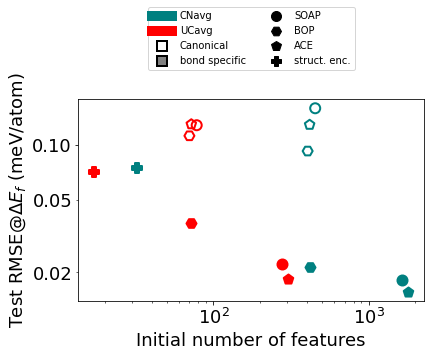

In [111]:
fig = plt.figure(figsize=(figw, figh*1.4))
axs = fig.add_axes([0.15, 0.1, 0.8, 0.5])
for (thedk, thetype, thecnav), data in VotedScores.groupby(['DK', 'type', 'iscnav']):
    if 'specific' in thedk:
        thefc=data['colors']
    else:
        thefc = 'none'
    axs.scatter(data['orig_len'], data['test'], ec=data['colors'], fc=thefc, linewidth=2, marker=markers[thetype], s=100)#, linewidth=linwidths[thedk]
axs.set_xscale('log')
axs.set_yscale('log', subs=[2,5,10])
axs.legend(handles=handles, bbox_to_anchor=(0.5,1.3), ncol=2, loc='center')
axs.yaxis.set_minor_formatter(FormatStrFormatter("%.2f"))
axs.yaxis.set_major_formatter(FormatStrFormatter("%.2f"))
axs.set_xlabel('Initial number of features')
axs.set_ylabel('Test RMSE@$\Delta E_f$ (meV/atom)')
fig.savefig(f'{system}/graphs/Figure_{system}_VotedRegressor_{target_case}_{nameforfile}.pdf')

what we can add is a second panel with final num of features vs test rmse, and there we could see that for bop we remove less num of feat and we have a quite good final rmse with less features as with ACE. In the case of ACE the number of features taken out is also much bigger. 

In [112]:
VotedScores[~VotedScores.index.get_level_values(1).str.contains("^0.6|^0.8")]

test     train  orig_len  \
Kernel Ridge 0.7dProjections 0.5OS BOP          0.021383  0.009072       417   
             0.7dProjections 0.5OS BOP no CNAV  0.037295  0.022984        72   
             ACE                                0.015711  0.007089      1803   
             ACE no CNAV                        0.018480  0.009414       303   
             Canonical ACE                      0.129839  0.118894       417   
             Canonical ACE no CNAV              0.130723  0.118860        72   
             Canonical BOP                      0.093085  0.083219       405   
             Canonical BOP no CNAV              0.112912  0.089237        70   
             SOAP_canonicalW_small              0.160003  0.132761       453   
             SOAP_canonicalW_small no CNAV      0.129078  0.120286        78   
             SOAP_specific_small                0.018157  0.007219      1653   
             SOAP_specific_small no CNAV        0.022146  0.013968       278   
             dataset                            0.074732  0.057352        32   
             dataset no CNAV                    0.071394  0.078073        17   

                                                 iscnav                type  \
Kernel Ridge 0.7dProjections 0.5OS BOP             CNAV                 BOP   
             0.7dProjections 0.5OS BOP no CNAV  no CNAV                 BOP   
             ACE                                   CNAV                 ACE   
             ACE no CNAV                        no CNAV                 ACE   
             Canonical ACE                         CNAV                 ACE   
             Canonical ACE no CNAV              no CNAV                 ACE   
             Canonical BOP                         CNAV                 BOP   
             Canonical BOP no CNAV              no CNAV                 BOP   
             SOAP_canonicalW_small                 CNAV                SOAP   
             SOAP_canonicalW_small no CNAV      no CNAV                SOAP   
             SOAP_specific_small                   CNAV                SOAP   
             SOAP_specific_small no CNAV        no CNAV                SOAP   
             dataset                               CNAV  structure encoding   
             dataset no CNAV                    no CNAV  structure encoding   

                                                       DK markers colors  
Kernel Ridge 0.7dProjections 0.5OS BOP           specific       H   teal  
             0.7dProjections 0.5OS BOP no CNAV   specific       H    red  
             ACE                                 specific       p   teal  
             ACE no CNAV                         specific       p    red  
             Canonical ACE                      canonical       p   teal  
             Canonical ACE no CNAV              canonical       p    red  
             Canonical BOP                      canonical       H   teal  
             Canonical BOP no CNAV              canonical       H    red  
             SOAP_canonicalW_small              canonical       o   teal  
             SOAP_canonicalW_small no CNAV      canonical       o    red  
             SOAP_specific_small                 specific       o   teal  
             SOAP_specific_small no CNAV         specific       o    red  
             dataset                             specific       P   teal  
             dataset no CNAV                     specific       P    red

In [113]:
PlotVotedScores = 1000*VotedScores[~VotedScores.index.get_level_values(1).str.contains('^0.6|^0.8')]

In [114]:
unstack = PlotVotedScores.unstack(level=0).sort_index()

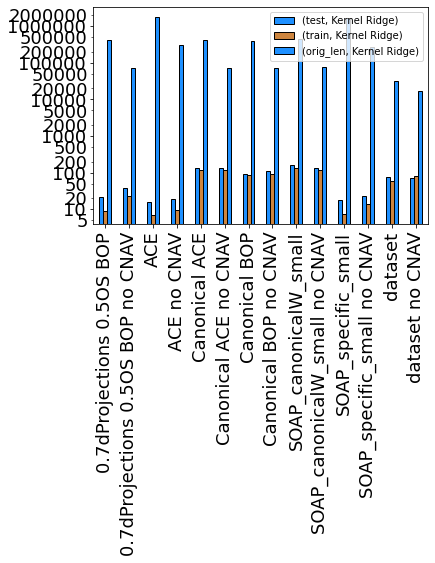

In [115]:
ax = PlotVotedScores.unstack(level=0).sort_index().plot.bar(
    color = ['dodgerblue', 'peru'], edgecolor = 'black'
)#.sort_values(by=('test', ModelName), ascending=False)*1000).plot.bar()
ax.set_yscale('log', subs=[2, 5, 10])
ax.get_legend().set_title('')
ax.tick_params(axis='y', which = 'minor')                                                                                                     
ax.yaxis.set_minor_formatter(FormatStrFormatter("%.0f"))
ax.yaxis.set_major_formatter(FormatStrFormatter("%.0f"))

# Feature Importances 

In [116]:
def loop_get_importances(voting_regressor):
    importances = {}
    for combi, estimator in voting_regressor.items():
        print(combi[1])
        X = DS.Features[combi[1]]#[selected]
        allimportances = get_importances(estimator , X,  DS.target)
        importances[combi] =allimportances #  [allimportances['importances_mean']>=allimportances['importances_mean']['random']]
    for (modelname, name),timportances in importances.items():
        timportances.sort_values(by='importances_mean', inplace=True, ascending=False)
    return importances


In [117]:
def plot_importances(importances):
    for name, timp in importances.items():
        fig, ax = plt.subplots(figsize=(12, 8))
        x = timp['importances_mean'][:20]
        sns.barplot(y=timp.index[:20], x=x , ax=ax, color='Purple')
        ylabels = [get_str_formatted(fname) for fname in x.index]
        ax.set_xscale('log')
        ax.set_xlabel('permutation importance')
        ax.set_yticklabels(ylabels, fontsize=12)
        fig.suptitle(name[1].replace('dataset', 'polyhedra'))
        fig.tight_layout()

In [118]:
importances_file = os.path.join(f'Fe-Mo/results/{ModelName.replace(" ","")}_inportances.pkl')
if not os.path.exists(importances_file):
    importances = loop_get_importances(voting_regressor)
    importances = pd.concat(importances, axis=0)
else:
    importances = pd.read_pickle(importances_file)
importances.to_pickle(importances_file)

In [119]:
ModelName

'Kernel Ridge'

In [120]:
descritor_inseterest = ['ACE','0.7dProjections 0.5OS BOP', 'SOAP_specific_small' ]
nfeatures  = 40

Text(0.5, 0.01, 'permutation importance')

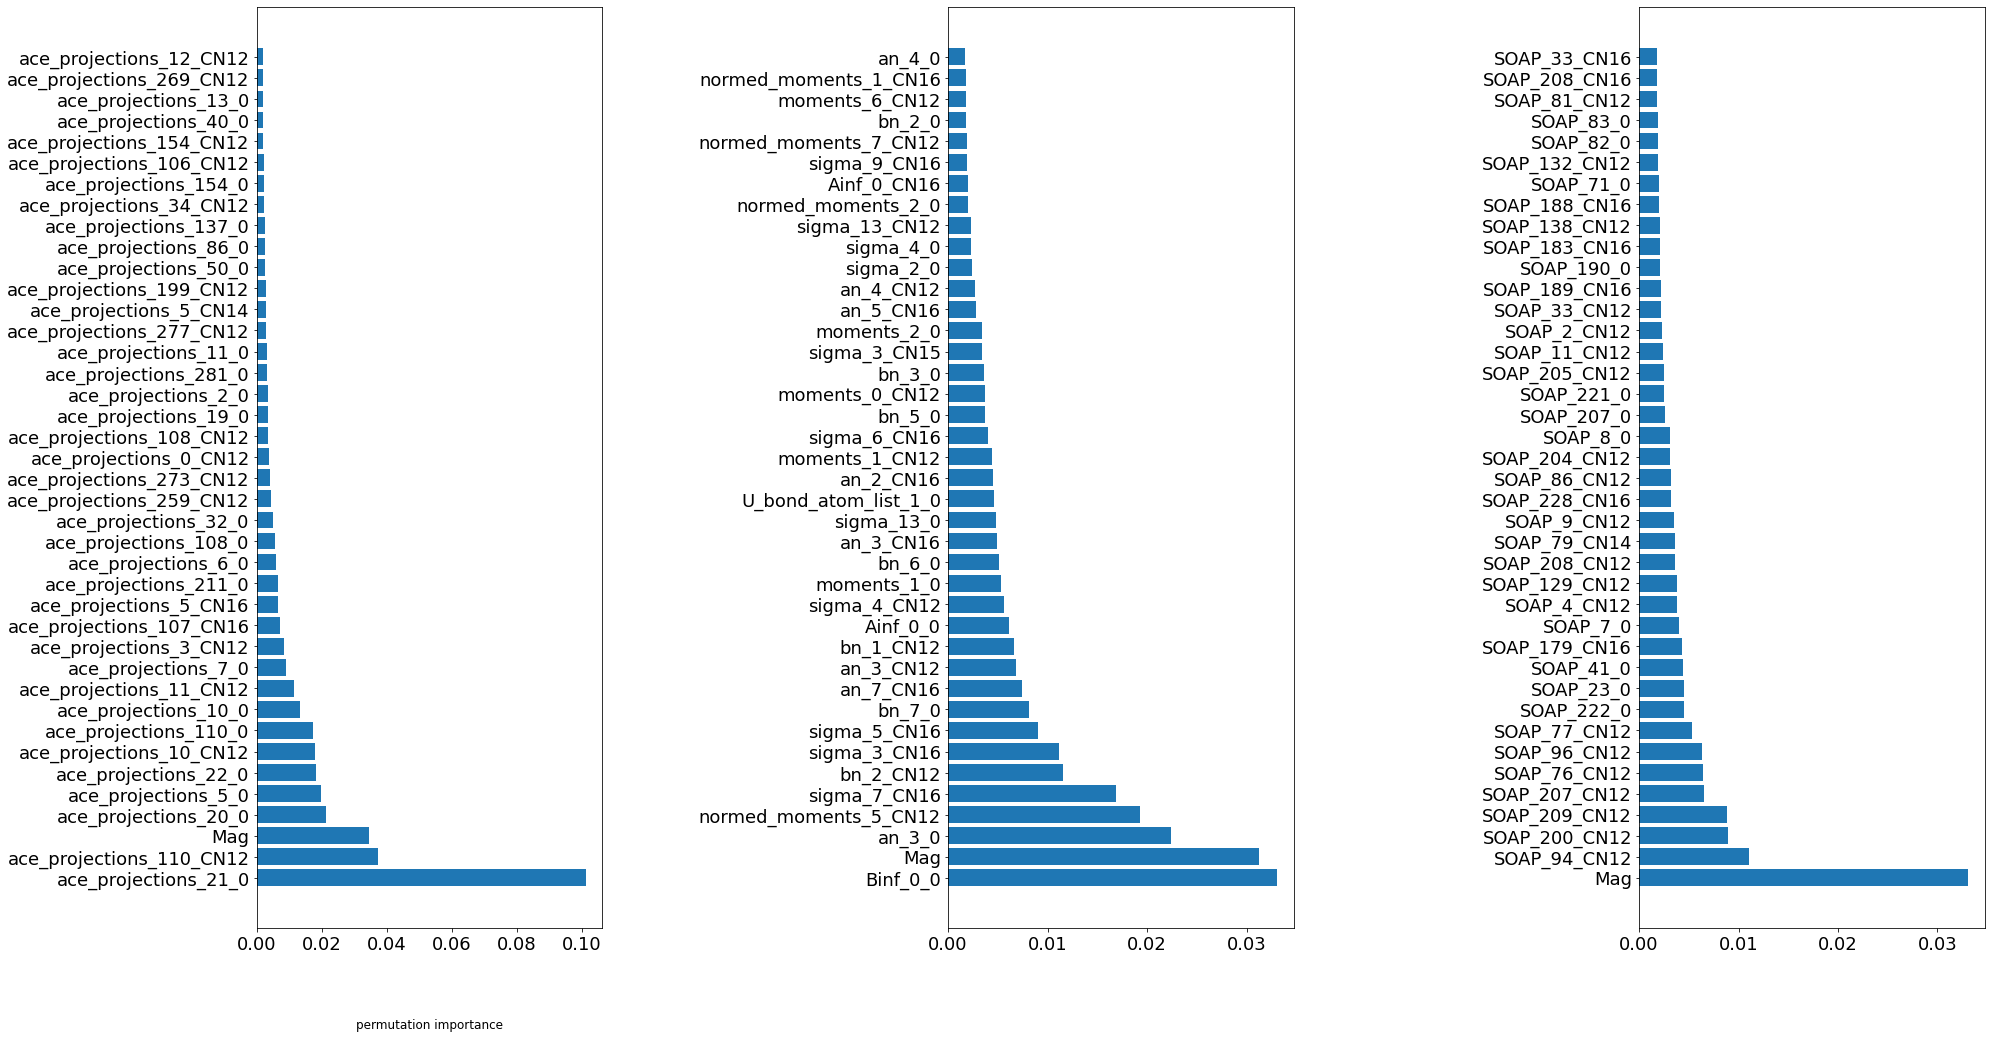

In [122]:
fw, fh = plt.rcParams['figure.figsize']
nplots = 3
axw = 1/nplots
#fig, ax = plt.subplots(1, 2*nplots, figsize=(fw*2*nplots, fh*nfeatures/10))
fig = plt.figure(figsize=(fw*nplots*0.8, fh*nfeatures/10))
for i, descriptor in enumerate(descritor_inseterest):
    axr = 2*(i+1)*axw
    axl = axr-axw
    thisax = fig.add_axes([axl, 0.1, axw, 0.8])
    this_importances = importances.loc[(ModelName, descriptor)]['importances_mean'].sort_values(ascending=False)
    thisax.barh(this_importances.index[:40], this_importances.values[:40])
fig.supxlabel('permutation importance')

In [ ]:
fig.add_subplot?

Signature: fig.add_subplot(*args, **kwargs)
Docstring:
Add an `~.axes.Axes` to the figure as part of a subplot arrangement.

Call signatures::

   add_subplot(nrows, ncols, index, **kwargs)
   add_subplot(pos, **kwargs)
   add_subplot(ax)
   add_subplot()

Parameters
----------
*args : int, (int, int, *index*), or `.SubplotSpec`, default: (1, 1, 1)
    The position of the subplot described by one of

    - Three integers (*nrows*, *ncols*, *index*). The subplot will
      take the *index* position on a grid with *nrows* rows and
      *ncols* columns. *index* starts at 1 in the upper left corner
      and increases to the right.  *index* can also be a two-tuple
      specifying the (*first*, *last*) indices (1-based, and including
      *last*) of the subplot, e.g., ``fig.add_subplot(3, 1, (1, 2))``
      makes a subplot that spans the upper 2/3 of the figure.
    - A 3-digit integer. The digits are interpreted as if given
      separately as three single-digit integers, i.e.
      ``f

In [135]:
for combi, bag_of_curves in FCresults.items():
    if combi not in importances.keys():
        continue
#    if '0.7dProjections 0.5OS BOP' in combi:
#        break

    relevant_importances = importances[combi].query('importances_mean > 0')/importances[combi].max()
    nrelevant = len(relevant_importances)

    locs = {}

    for featurename, importance in relevant_importances.iterrows():
        locs[featurename] = {i: curve.index.get_loc(featurename) for i, curve in enumerate(bag_of_curves) if featurename in curve.index}
            
    locs = pd.DataFrame.from_dict(locs, orient='index')#, dtype= int)
    locs['mean'] = locs.mean(axis=1)
    locs.sort_values(by='mean', inplace=True)
    locs['std'] = locs.drop(columns=['mean']).std(axis = 1)
    locs.dropna(inplace=True)
    if len(locs) == 0:
        continue
    indexing = pd.Series(np.linspace(0, len(relevant_importances)-1, len(relevant_importances)), index=relevant_importances.index, name='indexing')
    indexed_locs = pd.concat([indexing, locs], axis=1)
    fig, ax = plt.subplots(figsize=(8,0.5*(nrelevant+1)))
    fig.suptitle(f'{combi}', x=0, fontsize=12)
    axup= ax.twiny()
    ax.barh(y = indexing, width=relevant_importances['importances_mean'])
    axup.stem(indexed_locs['indexing'],indexed_locs['mean'],  orientation='horizontal', linefmt='r', markerfmt='dr')
    #axup.stem(indexing[locs.index],locs['mean'],  orientation='horizontal', linefmt='b', markerfmt='o')
    axup.set_xlim([0, locs['mean'].max()])
    axup.set_xlabel('position in selection vector')
    ax.set_yticks(indexing)
    labels = ax.set_yticklabels(relevant_importances.index)
    axup.spines['top'].set_color('red')
    #locs.plot(x='std')
    #axs[0].set_xscale('log')

In [130]:
combi

('Kernel Ridge', '0.7dProjections 100scf 8.0jii BOP no CNAV')

In [127]:
importances.index[0]

('Kernel Ridge', 'atomic', 'MagpieData mean GSvolume_pa')

In [121]:
locs

NameError: name 'locs' is not defined

# Prediction line 

In [ ]:
from sklearn.ensemble._voting import VotingRegressor as type_voting_regressor

In [ ]:
def get_bag_of_predictions(bag_of_regressors : type_voting_regressor, features_df  : pd.core.frame.DataFrame):
    bag_of_predictions = {}
    for name, regressor_in_bag in enumerate(bag_of_regressors):
        bag_of_predictions[name] = regressor_in_bag.predict(features_df)
        bag_of_predictions [name] = pd.Series(bag_of_predictions[name],name=name,  index=features_df.index)
    return pd.concat(bag_of_predictions, axis=1)
    

In [ ]:
predictions={}
stds={}
Prediction = {} 

In [ ]:
for name, regressor in voting_regressor.items():
    Prediction[name] = regressor.predict(Features[name[1]])
    Prediction[name] = pd.DataFrame(Prediction[name], index = Features[name[1]].index, columns=[DS.target_name])
    predictions[name] = get_bag_of_predictions(regressor.estimators_, Features[name[1]])
    stds[name] = predictions[name].std(axis=1)

# Predicted BS 

In [ ]:
predictedBS = copy.copy(DS.BS.loc[DS.target.index])

In [ ]:
for combi, prediction in Prediction.items():
    predictedBS[f'EF_nmhcp_{combi[1]}'] = prediction

In [ ]:
predictedBS.filter(regex='EF_nmhcp_*')

## save the prediction

In [ ]:
#predictedBS.to_pickle(os.path.join(DS.dataset, 'results', f'{DS.dataset}_{ModelName}_PredictedBS.pkl'))


In [ ]:
#iwanttoplot = {'atomic':'Matminer',
iwanttoplot = {'dataset': 'atomic+oneHot', test_bop_feature:'Bond specific BOP'}
#iwanttoplot = {'dataset': 'dataset', 'Projections OS BOP':'Projections OS BOP'}

In [ ]:
x_y = np.linspace(DS.target.min()-0.1, DS.target.max()+0.1, 2)
fig, ax = plt.subplots()
ax.plot(x_y, x_y, '--k', lw=2)
for name, legend in iwanttoplot.items():
    print(name, legend)
    legend = legend.replace('dataset', 'polyhedra').replace('Bond specific BOP', 'BOP')
    combi = (ModelName, name)
    if combi not in Prediction.keys():
        print(f'{combi} has not been processed yet')
        continue
    ax.plot(Prediction[combi].values, DS.target.values, 'o', markersize=8, markeredgecolor='k', color=colors[name], label=legend, )
ax.set_xlabel(r'predicted $\Delta E_f$ (eV/atom)')
ax.set_ylabel(r'True $\Delta E_f$ (eV/atom)')
ax.legend()
fig.savefig(os.path.join(DS.dataset,'graphs', f'{DS.dataset}_{ModelName}_predictionline_{target_case}.pdf'))

# Recursivity

REDO RECURSIVITY TESTS
 - redefine model
 - refit model

In [ ]:
Tester = DatasetTester()

In [ ]:
from importlib.machinery import SourceFileLoader
Tester = SourceFileLoader('Tester', 'Tools/DatasetTools/DatasetOperator.py').load_module().DatasetTester()
# from Tools.DatasetTools.DatasetOperator import Dataset
# DS = SourceFileLoader('DS', 'Tools/DatasetTools/DatasetOperator.py').load_module().Dataset('Fe-Mo')
# Tester = SourceFileLoader('Tester', 'Tools/DatasetTools/DatasetOperator.py').load_module().DatasetTester()
# samplesplit = DS.get_samplesplit()

In [ ]:
import copy

In [ ]:
RecursivityModels = copy.deepcopy(Models[ModelName])

# Fits on reduced features 

In [ ]:
ReducedFittedModels = {}

In [ ]:
Reduced_features_fitting_location = os.path.join(DS.resultslocation, f'ReducedFeaturesCVSearch_{target_case}.pkl')

In [ ]:
#if os.path.exists(Reduced_features_fitting_location):
#    with open(Reduced_features_fitting_location, 'rb') as pkl:
#        ReducedFittedModels = pickle.load(pkl)

In [ ]:
MO.modeloptions

In [ ]:
maxorders = [8, 10, 12, 14, 16]
for name, model in Models.items():
    if name != ModelName:
        continue
    progress = tqdm(product(Features.items(), maxorders), total=len(maxorders)*len(Features))
    for (key, features), maxorder in progress:  # maxorder in range(4,9):
        progress.set_description(name+', '+key+', '+str(maxorder)+':  ')
        if (name, key, maxorder) in ReducedFittedModels.keys():
            continue
        if 'no CNAV' in key:
            continue
        if 'BOP' not in key:
            continue
        if 'Projections' not in key:
            continue
        if (name, key, maxorder) in ReducedFittedModels.keys():
            continue
        if maxorder < 10:
            regexstr = f'^(?!.*_[{maxorder}-9]_.*|.*_1[0-9]_.*)'
        else:
            regexstr = f'^(?!.*_1[{maxorder - 10}-9]_.*)'
#        for key, features in progress: #Features.items():
        model = GridSearchCV(
            Models[name],
            MO.modeloptions[name], 
            scoring='neg_root_mean_squared_error', 
            cv = 5,#samplefolds,
            return_train_score= True,
        )
        if 'BOP' in key:
            reducedfeatures = features.filter(regex=regexstr)
        else:
            reducedfeatures = features
        ReducedFittedModels[(name, key, maxorder)] = model.fit(reducedfeatures, DS.target)

In [ ]:
with open(Reduced_features_fitting_location, 'wb') as pkl:
    pickle.dump(ReducedFittedModels, pkl)

In [ ]:
somecombi = (ModelName, 'Projections BOP')

In [ ]:
features_in_reduced = pd.Index(ReducedFittedModels[somecombi+(16,)].feature_names_in_)

In [ ]:
best_scores_reduced = collect_best_scores(ReducedFittedModels)

In [ ]:
model = best_scores_reduced.index.get_level_values(0)

In [ ]:
test_scores_vs_max = best_scores_reduced.unstack().transpose().loc['test'].dropna(axis=1)

In [ ]:
full_model_test_scores = best_scores_reduced.unstack().transpose().loc['test']

In [ ]:
fig, ax = plt.subplots(figsize=(15, 8))
for combi in test_scores_vs_max.columns:
#    if 'BOP' not in combi[1]:
#        continue
#    if 'Canonical' in combi[1]:
#        continue
#    if 'dataset' not in combi[1]:
#        continue
    drmse = (test_scores_vs_max[combi].values - test_scores_vs_max[combi].values[-1])*1000  # - full_model_test_scores[combi[0]][combi[1]]*1000
    l = ax.plot(test_scores_vs_max[combi].index, drmse, label=combi[1])[0]
#    ax.axhline(full_model_test_scores[combi[0]][combi[1]]*1000,ls='--', color=l.get_color())
ax.legend(bbox_to_anchor = (1, 1))
ax.set_ylabel(r'$\Delta$ test RMSE($\Delta E_f$) (meV/atom)')
ax.set_xlabel(r'max order in recursion features: $a_{1,..,n/2}, b_{1,..,n/2}, \mu_{1,..,n}, \sigma_{1,...,n}$')
fig.tight_layout()
fig.savefig(os.path.join(DS.dataset, 'graphs', f'{DS.dataset}_full_recursivity_{target_case}.eps'))

# Errors by phase by model

In [ ]:
train_errors = {}
rmse = {}

In [ ]:
absolute_errors = {}

In [ ]:
iwanttoseeerrors = ['0.7 Projections OS BOP', 'SOAP_specific', 'ACE']

In [ ]:
for combi, thisprediction in Prediction.items(): # voting_regressor.items():
    if 'sOS' in combi[1]:
        continue
    if combi[1] not in iwanttoseeerrors:
        continue
    print(combi)
    absolute_errors[combi] = thisprediction.sub(DS.target, axis=0)
    rmse[combi] = {}
    for phase in DS.BS.Phase.unique():
        thiserrors = absolute_errors[combi][DS.BS.Phase == phase]**2
        rmse[combi][phase] =  np.sqrt(thiserrors.sum()/len(thiserrors)).values[0]
    rmse[combi]['total'] = np.sqrt((thisprediction.sub(DS.target, axis=0)**2/len(thisprediction)).sum(axis=0)).values[0]
    rmse[combi]['test'] = np.sqrt(
        (
            (thisprediction.loc[DS.samplesplit['test']].sub(DS.target[DS.samplesplit['test']], axis=0)**2).sum()/len(DS.samplesplit['test'])
        ).values[0]
    )

In [ ]:
rmse

In [ ]:
width = plt.rcParams['figure.figsize'][0]*len(iwanttoseeerrors)*(3/5)
height = plt.rcParams['figure.figsize'][1]
fig, axes = plt.subplots(1, len(rmse),sharey=True, figsize=(width, height))
for (combi, thiserrors), ax in zip(absolute_errors.items(), axes):
    sns.violinplot(
        y=absolute_errors[combi][target_case].map(np.log10), 
        x=DS.StructureNames, hue=DS.Features['dataset']['Mag'], split=True, ax=ax
    )
    ax.axhline(np.log10(rmse[combi]['total']),color='k', label='rmse')
    ax.get_legend().remove()
    ax.set_xlabel('')
    ax.set_ylabel(combi[1].replace('_specific', ''))
fig.tight_layout()

In [ ]:
rmsedf = pd.DataFrame.from_dict(rmse, orient = 'index')

In [ ]:
rmsedf.sort_values(by=(ModelName, '0.7 Projections OS BOP'), axis = 1, inplace=True)

In [ ]:
rmsedf.sort_values(by='total', inplace=True)

In [ ]:
important = [(ModelName, '0.7 Projections OS BOP'), (ModelName, 'ACE'), (ModelName, 'SOAP_specific')]

In [ ]:
from matplotlib.colors import LogNorm, Normalize
ax = sns.heatmap(rmsedf.loc[important]*1000,  cbar_kws={'label': 'RMSE (meV /  at)'}, norm=LogNorm())